# Task 1a: Unstructured Pruning - Sensitivity Analysis

In [2]:
# Setup for Colab and Local environments
import sys
import os

# Check if running on Colab
try:
    import google.colab # type: ignore
    IN_COLAB = True
    print("Running on Google Colab")

    # Mount Google Drive
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')

    # Add project directory to Python path
    # Change this path to match your Google Drive folder structure
    PROJECT_PATH = '/content/drive/MyDrive/AI624-Edge-Devices/pa1.1'
    sys.path.append(PROJECT_PATH)
    print(f"Added {PROJECT_PATH} to Python path")

except ImportError:
    IN_COLAB = False
    print("Running locally")

# Enable PyTorch MPS fallback (macOS only)
from utils import enablePytorchFallback
enablePytorchFallback()

Running on Google Colab
Mounted at /content/drive
Added /content/drive/MyDrive/AI624-Edge-Devices/pa1.1 to Python path


In [3]:
# Import required modules
import os
import torch
from utils import getDeviceFromHardware, get_base_path
from task1a import VGG16_Pruning

In [4]:
# Auto-detect device
DEVICE = getDeviceFromHardware()
print(f"Using device: {DEVICE}")

# Set base path (auto-detects local vs Colab)
BASE_PATH = get_base_path(gdrive_relative_path="/content/drive/MyDrive/AI624-Edge-Devices/pa1.1")
print(f"Base path: {BASE_PATH}")

# Define sparsity levels to test
SPARSITY_LEVELS = [0.0, 0.1, 0.2, 0.5, 0.7, 0.8, 0.9]
print(f"\nSparsity levels to test: {[f'{s*100:.0f}%' for s in SPARSITY_LEVELS]}")

Using device: cuda
Detected Google Colab environment
Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive mounted successfully
Using specified path: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1
Base path: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1

Sparsity levels to test: ['0%', '10%', '20%', '50%', '70%', '80%', '90%']


# CIFAR-100 Sensitivity Analysis

In [5]:
# Create CIFAR-10 model instance with pruning capabilities
cifar10_model = VGG16_Pruning(num_classes=10, is_pruned=False)
print("✓ CIFAR-10 model architecture created")

✓ CIFAR-10 model architecture created


In [6]:
# Load pre-trained weights
cifar10_model_path = os.path.join(BASE_PATH, 'models/cifar10_vgg16.pt')
cifar10_model.load(cifar10_model_path, device=DEVICE)
print("✓ CIFAR-10 model weights loaded")

Loading model from /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/models/cifar10_vgg16.pt
Model loaded successfully
✓ CIFAR-10 model weights loaded


In [7]:
# Get datasets
cifar10_train_dataset, cifar10_test_dataset = cifar10_model.get_train_test_split(base_path=BASE_PATH)
print(f"✓ CIFAR-10 datasets loaded")
print(f"  Train size: {len(cifar10_train_dataset)}")
print(f"  Test size: {len(cifar10_test_dataset)}")

Dataset found at /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/datasets/cifar-10-batches-py
✓ CIFAR-10 datasets loaded
  Train size: 50000
  Test size: 10000


In [8]:
# Create dataloaders
cifar10_train_loader, cifar10_test_loader = cifar10_model.get_data_loaders(
    cifar10_train_dataset,
    cifar10_test_dataset,
    batch_size=128
)
print("✓ CIFAR-10 dataloaders created")
print(f"  Train batches: {len(cifar10_train_loader)}")
print(f"  Test batches: {len(cifar10_test_loader)}")

✓ CIFAR-10 dataloaders created
  Train batches: 391
  Test batches: 79


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [9]:
# Perform comprehensive sensitivity analysis
cifar10_sensitivity_results, cifar10_baseline_accuracy = cifar10_model.perform_sensitivity_analysis(
    data_loader=cifar10_test_loader,
    device=DEVICE,
    sparsity_levels=SPARSITY_LEVELS,
    base_path=BASE_PATH
)


FOUND SAVED SENSITIVITY ANALYSIS RESULTS
Loading from: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sensitivity_analysis/cifar10_sensitivity_results.pkl
✓ Loaded results for 16 layers
✓ Baseline accuracy: 94.16%
✓ Sparsity levels: ['0%', '10%', '20%', '50%', '70%', '80%', '90%']

✓ All layers already analyzed. Returning cached results.




✓ Sensitivity curves saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/cifar10_sensitivity_analysis.png


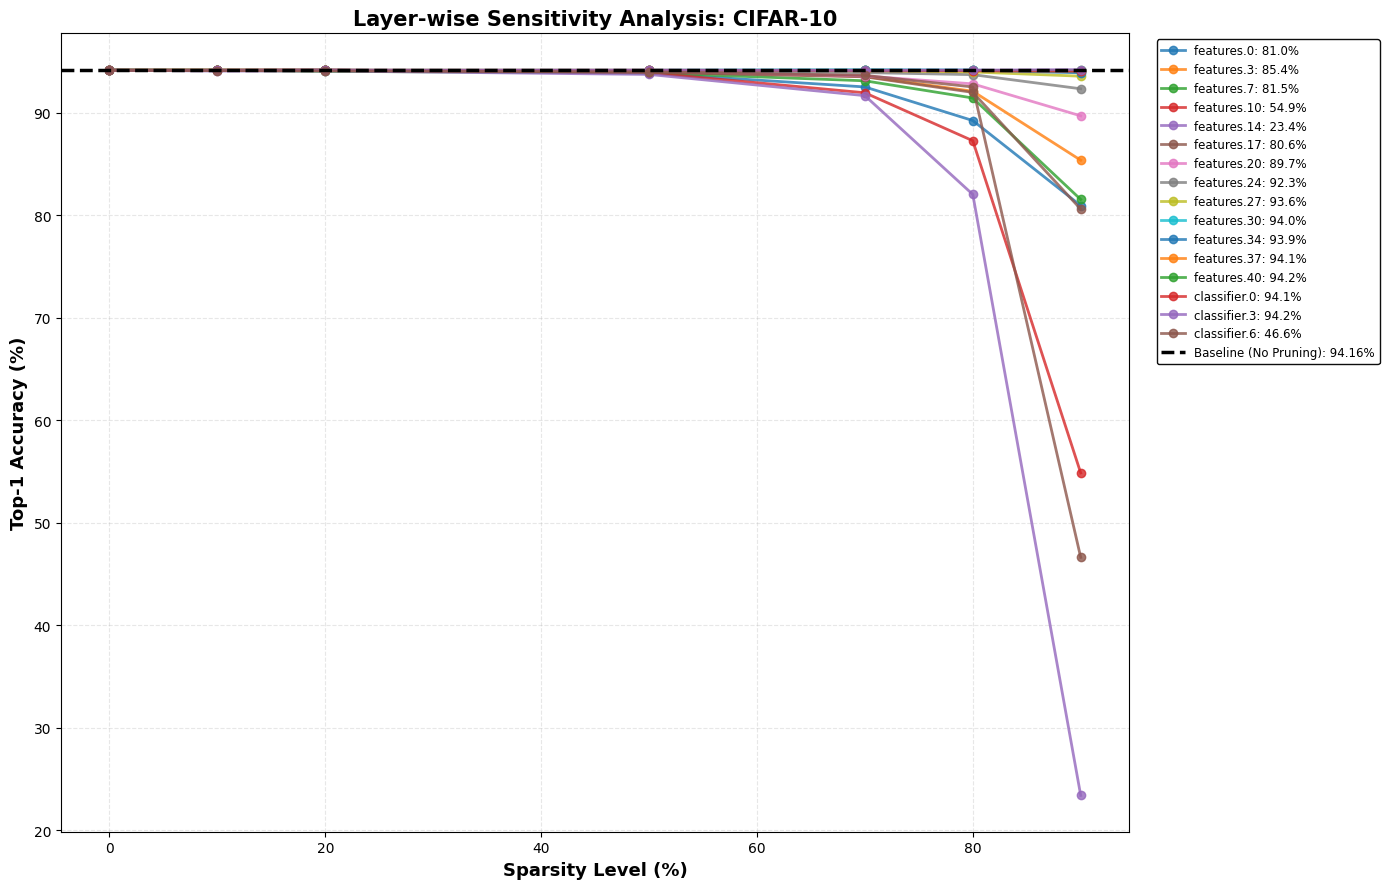

In [ ]:
cifar10_model.plot_sensitivity_curves(
    sensitivity_results=cifar10_sensitivity_results,
    sparsity_levels=SPARSITY_LEVELS,
    baseline_accuracy=cifar10_baseline_accuracy,
    base_path=BASE_PATH
)

In [11]:
# Print summary table
cifar10_model.print_sensitivity_summary(
    sensitivity_results=cifar10_sensitivity_results,
    sparsity_levels=SPARSITY_LEVELS,
    baseline_accuracy=cifar10_baseline_accuracy
)


SENSITIVITY ANALYSIS SUMMARY

Baseline Top-1 Accuracy: 94.16%

Layer                |    0% |   10% |   20% |   50% |   70% |   80% |   90% | 
-------------------------------------------------------------------------------
features.0           |  +0.0 |  +0.0 |  +0.0 |  +0.3 |  +1.6 |  +4.9 | +13.2 | 
features.3           |  +0.0 |  +0.0 |  +0.0 |  +0.1 |  +0.6 |  +2.0 |  +8.8 | 
features.7           |  +0.0 |  +0.0 |  +0.1 |  +0.3 |  +1.0 |  +2.7 | +12.6 | 
features.10          |  +0.0 |  +0.0 |  -0.0 |  +0.2 |  +2.2 |  +6.9 | +39.3 | 
features.14          |  +0.0 |  +0.1 |  +0.1 |  +0.4 |  +2.5 | +12.1 | +70.8 | 
features.17          |  +0.0 |  +0.0 |  -0.0 |  +0.2 |  +0.6 |  +2.2 | +13.5 | 
features.20          |  +0.0 |  +0.0 |  -0.0 |  +0.1 |  +0.6 |  +1.3 |  +4.5 | 
features.24          |  +0.0 |  +0.0 |  +0.0 |  +0.1 |  +0.2 |  +0.4 |  +1.8 | 
features.27          |  +0.0 |  +0.0 |  +0.0 |  +0.0 |  +0.0 |  +0.2 |  +0.6 | 
features.30          |  +0.0 |  +0.0 |  +0.0 |  +0.0 |  

# CIFAR-100 Sensitivity Analysis

In [12]:
# Create CIFAR-100 model instance with pruning capabilities
cifar100_model = VGG16_Pruning(num_classes=100, is_pruned=False)
print("✓ CIFAR-100 model architecture created")

✓ CIFAR-100 model architecture created


In [13]:
# Load pre-trained weights
cifar100_model_path = os.path.join(BASE_PATH, 'models/cifar100_vgg16.pt')
cifar100_model.load(cifar100_model_path, device=DEVICE)
print("✓ CIFAR-100 model weights loaded")

Loading model from /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/models/cifar100_vgg16.pt
Model loaded successfully
✓ CIFAR-100 model weights loaded


In [14]:
# Get datasets
cifar100_train_dataset, cifar100_test_dataset = cifar100_model.get_train_test_split(base_path=BASE_PATH)
print(f"✓ CIFAR-100 datasets loaded")
print(f"  Train size: {len(cifar100_train_dataset)}")
print(f"  Test size: {len(cifar100_test_dataset)}")

Dataset found at /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/datasets/cifar-100-python
✓ CIFAR-100 datasets loaded
  Train size: 50000
  Test size: 10000


In [15]:
# Create dataloaders
cifar100_train_loader, cifar100_test_loader = cifar100_model.get_data_loaders(
    cifar100_train_dataset,
    cifar100_test_dataset,
    batch_size=128
)
print("✓ CIFAR-100 dataloaders created")
print(f"  Train batches: {len(cifar100_train_loader)}")
print(f"  Test batches: {len(cifar100_test_loader)}")

✓ CIFAR-100 dataloaders created
  Train batches: 391
  Test batches: 79


In [16]:
# Perform comprehensive sensitivity analysis
cifar100_sensitivity_results, cifar100_baseline_accuracy = cifar100_model.perform_sensitivity_analysis(
    data_loader=cifar100_test_loader,
    device=DEVICE,
    sparsity_levels=SPARSITY_LEVELS,
    base_path=BASE_PATH
)


FOUND SAVED SENSITIVITY ANALYSIS RESULTS
Loading from: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sensitivity_analysis/cifar100_sensitivity_results.pkl
✓ Loaded results for 16 layers
✓ Baseline accuracy: 74.00%
✓ Sparsity levels: ['0%', '10%', '20%', '50%', '70%', '80%', '90%']

✓ All layers already analyzed. Returning cached results.




✓ Sensitivity curves saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/cifar100_sensitivity_analysis.png


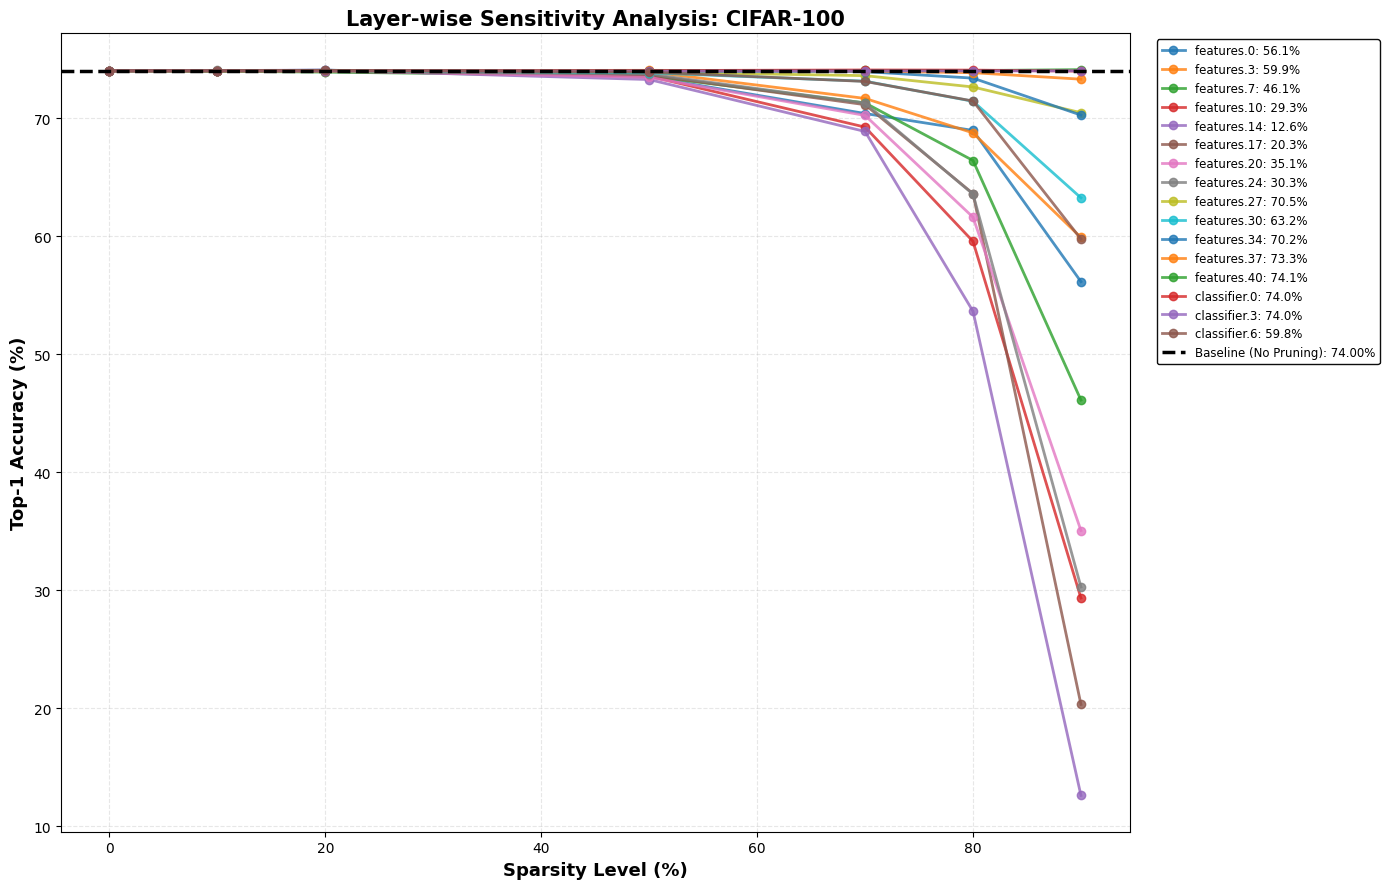

In [ ]:
cifar100_model.plot_sensitivity_curves(
    sensitivity_results=cifar100_sensitivity_results,
    sparsity_levels=SPARSITY_LEVELS,
    baseline_accuracy=cifar100_baseline_accuracy,
    base_path=BASE_PATH
)

In [18]:
# Print summary table
cifar100_model.print_sensitivity_summary(
    sensitivity_results=cifar100_sensitivity_results,
    sparsity_levels=SPARSITY_LEVELS,
    baseline_accuracy=cifar100_baseline_accuracy,
)


SENSITIVITY ANALYSIS SUMMARY

Baseline Top-1 Accuracy: 74.00%

Layer                |    0% |   10% |   20% |   50% |   70% |   80% |   90% | 
-------------------------------------------------------------------------------
features.0           |  +0.0 |  +0.0 |  -0.1 |  +0.5 |  +3.6 |  +5.0 | +17.9 | 
features.3           |  +0.0 |  +0.0 |  +0.0 |  +0.1 |  +2.3 |  +5.3 | +14.1 | 
features.7           |  +0.0 |  +0.0 |  +0.1 |  +0.4 |  +2.7 |  +7.6 | +27.9 | 
features.10          |  +0.0 |  -0.0 |  -0.0 |  +0.5 |  +4.8 | +14.5 | +44.7 | 
features.14          |  +0.0 |  -0.0 |  -0.1 |  +0.7 |  +5.1 | +20.4 | +61.4 | 
features.17          |  +0.0 |  -0.0 |  +0.0 |  +0.4 |  +2.9 | +10.4 | +53.7 | 
features.20          |  +0.0 |  +0.0 |  +0.0 |  +0.5 |  +3.8 | +12.4 | +38.9 | 
features.24          |  +0.0 |  -0.0 |  +0.1 |  +0.3 |  +2.7 | +10.5 | +43.7 | 
features.27          |  +0.0 |  +0.0 |  +0.0 |  +0.1 |  +0.4 |  +1.4 |  +3.5 | 
features.30          |  +0.0 |  +0.0 |  -0.0 |  +0.2 |  

In [ ]:
cifar10_layer_sparsity = {
    'features.0': 0.65,
    'features.3': 0.75,
    'features.7': 0.75,
    'features.10': 0.60,
    'features.14': 0.50,
    'features.17': 0.75,
    'features.20': 0.80,
    'features.24': 0.85,
    'features.27': 0.90,
    'features.30': 0.90,
    'features.34': 0.90,
    'features.37': 0.90,
    'features.40': 0.90,
    'classifier.0': 0.90,
    'classifier.3': 0.90,
    'classifier.6': 0.60,
}

In [20]:
# Calculate overall sparsity for CIFAR-10
cifar10_overall_sparsity, cifar10_total_params, cifar10_pruned_params = cifar10_model.calculate_overall_sparsity(
    cifar10_layer_sparsity
)

print("\nCIFAR-10 Overall Sparsity Calculation")
print("=" * 80)
print(f"Total Parameters:       {cifar10_total_params:,}")
print(f"Pruned Parameters:      {cifar10_pruned_params:,}")
print(f"Overall Sparsity Ratio: {cifar10_overall_sparsity*100:.2f}%")
print(f"Remaining Parameters:   {cifar10_total_params - cifar10_pruned_params:,}")
print("=" * 80)


CIFAR-10 Overall Sparsity Calculation
Total Parameters:       15,239,872
Pruned Parameters:      13,328,683
Overall Sparsity Ratio: 87.46%
Remaining Parameters:   1,911,189


In [ ]:
cifar100_layer_sparsity = {
    'features.0': 0.60,
    'features.3': 0.65,
    'features.7': 0.60,
    'features.10': 0.45,
    'features.14': 0.40,
    'features.17': 0.50,
    'features.20': 0.50,
    'features.24': 0.50,
    'features.27': 0.80,
    'features.30': 0.75,
    'features.34': 0.80,
    'features.37': 0.85,
    'features.40': 0.90,
    'classifier.0': 0.90,
    'classifier.3': 0.90,
    'classifier.6': 0.75,
}

In [22]:
# Calculate overall sparsity for CIFAR-100
cifar100_overall_sparsity, cifar100_total_params, cifar100_pruned_params = cifar100_model.calculate_overall_sparsity(
    cifar100_layer_sparsity
)

print("\nCIFAR-100 Overall Sparsity Calculation")
print("=" * 80)
print(f"Total Parameters:       {cifar100_total_params:,}")
print(f"Pruned Parameters:      {cifar100_pruned_params:,}")
print(f"Overall Sparsity Ratio: {cifar100_overall_sparsity*100:.2f}%")
print(f"Remaining Parameters:   {cifar100_total_params - cifar100_pruned_params:,}")
print("=" * 80)


CIFAR-100 Overall Sparsity Calculation
Total Parameters:       15,285,952
Pruned Parameters:      11,616,569
Overall Sparsity Ratio: 76.00%
Remaining Parameters:   3,669,383


# Apply Pruning and Fine-tune Models

In [23]:
# Apply layer-wise pruning to CIFAR-10 model
print("="*80)
print("APPLYING PRUNING TO CIFAR-10 MODEL")
print("="*80)

# Apply pruning and get masks
cifar10_pruning_masks = cifar10_model.apply_layerwise_pruning(cifar10_layer_sparsity)

# Evaluate accuracy after pruning (before fine-tuning)
print("\nEvaluating pruned model (before fine-tuning)...")
cifar10_pruned_acc_before_ft, _ = cifar10_model.profile_accuracy(cifar10_test_loader, DEVICE)
print(f"Accuracy after pruning: {cifar10_pruned_acc_before_ft:.2f}%")
print(f"Accuracy drop: {cifar10_baseline_accuracy - cifar10_pruned_acc_before_ft:.2f}%")
print(f"Overall sparsity: {cifar10_overall_sparsity*100:.2f}%")

APPLYING PRUNING TO CIFAR-10 MODEL

APPLYING LAYERWISE PRUNING

features.27:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.30:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.34:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.37:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.40:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

classifier.0:
  Shape: (512, 512)
  Parameters: 262,144
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

classifier.3:
  Shape: (512, 512)
  Parameters: 262,144
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.24:
  Shape: (512, 256, 3, 3)
  Parameters: 1,179,648
  Target Sparsity: 85.0%
  Actual Sparsity: 85.0%

features.20:
  Shape: (256, 256, 3, 3)

In [ ]:
# Fine-tuning configuration
import torch.nn as nn
import torch.optim as optim

print("="*80)
print("FINE-TUNING CIFAR-10 PRUNED MODEL")
print("="*80)
print(f"Overall sparsity: {cifar10_overall_sparsity*100:.2f}%")
print(f"Accuracy before fine-tuning: {cifar10_pruned_acc_before_ft:.2f}%")
print(f"Target accuracy: ≥{cifar10_baseline_accuracy - 5:.2f}% (≤5% drop)")
print()

# Define optimizer, scheduler, and criterion
cifar10_optimizer = optim.SGD(
    cifar10_model.model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

cifar10_scheduler = optim.lr_scheduler.MultiStepLR(
    cifar10_optimizer,
    milestones=[60, 120, 160],
    gamma=0.2
)

cifar10_criterion = nn.CrossEntropyLoss()

# Create sparsity callback to maintain pruning masks during training
cifar10_sparsity_callback = cifar10_model.create_sparsity_callback(
    cifar10_pruning_masks,
    DEVICE
)

# Define checkpoint path
cifar10_checkpoint_path = os.path.join(BASE_PATH, 'task1a/checkpoints/task1a_cifar10_finetuned.pt')
os.makedirs(os.path.dirname(cifar10_checkpoint_path), exist_ok=True)

# Fine-tune the model
# Target: Recover to within 5% of baseline (89.16% baseline - 5% = 84.16%)
cifar10_target_accuracy = cifar10_baseline_accuracy - 5.0

cifar10_best_accuracy = cifar10_model.fine_tune(
    train_loader=cifar10_train_loader,
    val_loader=cifar10_test_loader,
    device=DEVICE,
    optimizer=cifar10_optimizer,
    scheduler=cifar10_scheduler,
    criterion=cifar10_criterion,
    target_accuracy=cifar10_target_accuracy,
    checkpoint_path=cifar10_checkpoint_path,
    max_epochs=200,
    early_stop_patience=15,
    post_step_callback=cifar10_sparsity_callback 
)

print("\n" + "="*80)
print("CIFAR-10 FINE-TUNING COMPLETE")
print("="*80)
print(f"Best accuracy achieved: {cifar10_best_accuracy:.2f}%")
print(f"Baseline accuracy: {cifar10_baseline_accuracy:.2f}%")
print(f"Final accuracy drop: {cifar10_baseline_accuracy - cifar10_best_accuracy:.2f}%")
print(f"Overall sparsity: {cifar10_overall_sparsity*100:.2f}%")
print("="*80)

FINE-TUNING CIFAR-10 PRUNED MODEL
Overall sparsity: 87.46%
Accuracy before fine-tuning: 21.24%
Target accuracy: ≥89.16% (≤5% drop)

Fine-tuning to 89.16% accuracy (max 200 epochs)

Loading checkpoint from /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/checkpoints/task1a_cifar10_finetuned.pt
✓ Resumed from epoch 4, best accuracy: 91.85%

✓ Target accuracy 89.16% already achieved!
✓ Checkpoint has accuracy: 91.85%
✓ Skipping training - returning existing model

CIFAR-10 FINE-TUNING COMPLETE
Best accuracy achieved: 91.85%
Baseline accuracy: 94.16%
Final accuracy drop: 2.31%
Overall sparsity: 87.46%


In [25]:
# Save the fine-tuned model and pruning masks
cifar10_finetuned_model_path = os.path.join(BASE_PATH, 'task1a/models/task1a_cifar10_finetuned.pt')
cifar10_masks_path = os.path.join(BASE_PATH, 'task1a/pruning_masks/task1a_cifar10_masks.pt')

# Create directories
os.makedirs(os.path.dirname(cifar10_finetuned_model_path), exist_ok=True)
os.makedirs(os.path.dirname(cifar10_masks_path), exist_ok=True)

# Save model
cifar10_model.save(cifar10_finetuned_model_path)
print(f"✓ Fine-tuned model saved to: {cifar10_finetuned_model_path}")

# Save pruning masks
torch.save(cifar10_pruning_masks, cifar10_masks_path)
print(f"✓ Pruning masks saved to: {cifar10_masks_path}")

Saving model to /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/models/task1a_cifar10_finetuned.pt
Model saved successfully
✓ Fine-tuned model saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/models/task1a_cifar10_finetuned.pt
✓ Pruning masks saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/pruning_masks/task1a_cifar10_masks.pt


---

## CIFAR-100 Pruning & Fine-tuning

In [26]:
# Apply layer-wise pruning to CIFAR-100 model
print("="*80)
print("APPLYING PRUNING TO CIFAR-100 MODEL")
print("="*80)

# Apply pruning and get masks
cifar100_pruning_masks = cifar100_model.apply_layerwise_pruning(cifar100_layer_sparsity)

# Evaluate accuracy after pruning (before fine-tuning)
print("\nEvaluating pruned model (before fine-tuning)...")
cifar100_pruned_acc_before_ft, _ = cifar100_model.profile_accuracy(cifar100_test_loader, DEVICE)
print(f"Accuracy after pruning: {cifar100_pruned_acc_before_ft:.2f}%")
print(f"Accuracy drop: {cifar100_baseline_accuracy - cifar100_pruned_acc_before_ft:.2f}%")
print(f"Overall sparsity: {cifar100_overall_sparsity*100:.2f}%")

APPLYING PRUNING TO CIFAR-100 MODEL

APPLYING LAYERWISE PRUNING

features.40:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

classifier.0:
  Shape: (512, 512)
  Parameters: 262,144
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

classifier.3:
  Shape: (512, 512)
  Parameters: 262,144
  Target Sparsity: 90.0%
  Actual Sparsity: 90.0%

features.37:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 85.0%
  Actual Sparsity: 85.0%

features.34:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 80.0%
  Actual Sparsity: 80.0%

features.27:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 80.0%
  Actual Sparsity: 80.0%

features.30:
  Shape: (512, 512, 3, 3)
  Parameters: 2,359,296
  Target Sparsity: 75.0%
  Actual Sparsity: 75.0%

classifier.6:
  Shape: (100, 512)
  Parameters: 51,200
  Target Sparsity: 75.0%
  Actual Sparsity: 75.0%

features.3:
  Shape: (64, 64, 3, 3)
  Paramet

In [27]:
# Fine-tuning configuration
print("="*80)
print("FINE-TUNING CIFAR-100 PRUNED MODEL")
print("="*80)
print(f"Overall sparsity: {cifar100_overall_sparsity*100:.2f}%")
print(f"Accuracy before fine-tuning: {cifar100_pruned_acc_before_ft:.2f}%")
print(f"Target accuracy: ≥{cifar100_baseline_accuracy - 5:.2f}% (≤5% drop)")
print()

# Define optimizer, scheduler, and criterion
cifar100_optimizer = optim.SGD(
    cifar100_model.model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

cifar100_scheduler = optim.lr_scheduler.MultiStepLR(
    cifar100_optimizer,
    milestones=[60, 120, 160],
    gamma=0.2
)

cifar100_criterion = nn.CrossEntropyLoss()

# Create sparsity callback to maintain pruning masks during training
cifar100_sparsity_callback = cifar100_model.create_sparsity_callback(
    cifar100_pruning_masks,
    DEVICE
)

# Define checkpoint path
cifar100_checkpoint_path = os.path.join(BASE_PATH, 'task1a/checkpoints/task1a_cifar100_finetuned.pt')
os.makedirs(os.path.dirname(cifar100_checkpoint_path), exist_ok=True)

# Fine-tune the model
# Target: Recover to within 5% of baseline (74.00% baseline - 5% = 69.00%)
cifar100_target_accuracy = cifar100_baseline_accuracy - 5.0

cifar100_best_accuracy = cifar100_model.fine_tune(
    train_loader=cifar100_train_loader,
    val_loader=cifar100_test_loader,
    device=DEVICE,
    optimizer=cifar100_optimizer,
    scheduler=cifar100_scheduler,
    criterion=cifar100_criterion,
    target_accuracy=cifar100_target_accuracy,
    checkpoint_path=cifar100_checkpoint_path,
    max_epochs=200,
    early_stop_patience=15,
    post_step_callback=cifar100_sparsity_callback  # Maintain sparsity
)

print("\n" + "="*80)
print("CIFAR-100 FINE-TUNING COMPLETE")
print("="*80)
print(f"Best accuracy achieved: {cifar100_best_accuracy:.2f}%")
print(f"Baseline accuracy: {cifar100_baseline_accuracy:.2f}%")
print(f"Final accuracy drop: {cifar100_baseline_accuracy - cifar100_best_accuracy:.2f}%")
print(f"Overall sparsity: {cifar100_overall_sparsity*100:.2f}%")
print("="*80)

FINE-TUNING CIFAR-100 PRUNED MODEL
Overall sparsity: 76.00%
Accuracy before fine-tuning: 32.11%
Target accuracy: ≥69.00% (≤5% drop)

Fine-tuning to 69.0% accuracy (max 200 epochs)

Loading checkpoint from /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/checkpoints/task1a_cifar100_finetuned.pt
✓ Resumed from epoch 3, best accuracy: 69.94%

✓ Target accuracy 69.0% already achieved!
✓ Checkpoint has accuracy: 69.94%
✓ Skipping training - returning existing model

CIFAR-100 FINE-TUNING COMPLETE
Best accuracy achieved: 69.94%
Baseline accuracy: 74.00%
Final accuracy drop: 4.06%
Overall sparsity: 76.00%


In [28]:
# Save the fine-tuned model and pruning masks
cifar100_finetuned_model_path = os.path.join(BASE_PATH, 'task1a/models/task1a_cifar100_finetuned.pt')
cifar100_masks_path = os.path.join(BASE_PATH, 'task1a/pruning_masks/task1a_cifar100_masks.pt')

# Create directories
os.makedirs(os.path.dirname(cifar100_finetuned_model_path), exist_ok=True)
os.makedirs(os.path.dirname(cifar100_masks_path), exist_ok=True)

# Save model
cifar100_model.save(cifar100_finetuned_model_path)
print(f"✓ Fine-tuned model saved to: {cifar100_finetuned_model_path}")

# Save pruning masks
torch.save(cifar100_pruning_masks, cifar100_masks_path)
print(f"✓ Pruning masks saved to: {cifar100_masks_path}")

Saving model to /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/models/task1a_cifar100_finetuned.pt
Model saved successfully
✓ Fine-tuned model saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/models/task1a_cifar100_finetuned.pt
✓ Pruning masks saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/pruning_masks/task1a_cifar100_masks.pt


In [29]:
# Convert CIFAR-10 pruned model to COO sparse format
cifar10_sparse_tensors, cifar10_memory_stats = cifar10_model.convert_to_coo_sparse(cifar10_pruning_masks)


CONVERTING TO COO SPARSE FORMAT

features.0:
  Total params: 1,728
  Non-zeros: 604
  Sparsity: 65.05%
  Dense size: 0.01 MB
  Sparse size: 0.02 MB
  Compression: 0.32x

features.3:
  Total params: 36,864
  Non-zeros: 9,216
  Sparsity: 75.00%
  Dense size: 0.14 MB
  Sparse size: 0.32 MB
  Compression: 0.44x

features.7:
  Total params: 73,728
  Non-zeros: 18,432
  Sparsity: 75.00%
  Dense size: 0.28 MB
  Sparse size: 0.63 MB
  Compression: 0.44x

features.10:
  Total params: 147,456
  Non-zeros: 58,982
  Sparsity: 60.00%
  Dense size: 0.56 MB
  Sparse size: 2.02 MB
  Compression: 0.28x

features.14:
  Total params: 294,912
  Non-zeros: 147,456
  Sparsity: 50.00%
  Dense size: 1.12 MB
  Sparse size: 5.06 MB
  Compression: 0.22x

features.17:
  Total params: 589,824
  Non-zeros: 147,456
  Sparsity: 75.00%
  Dense size: 2.25 MB
  Sparse size: 5.06 MB
  Compression: 0.44x

features.20:
  Total params: 589,824
  Non-zeros: 117,964
  Sparsity: 80.00%
  Dense size: 2.25 MB
  Sparse size: 4.0

In [30]:
# Verify that COO sparse tensors match the original pruning masks
cifar10_verification_results = cifar10_model.verify_mask_coo_consistency(
    cifar10_pruning_masks,
    cifar10_sparse_tensors
)


VERIFYING MASK-COO CONSISTENCY

features.27: ✓ CONSISTENT
features.30: ✓ CONSISTENT
features.34: ✓ CONSISTENT
features.37: ✓ CONSISTENT
features.40: ✓ CONSISTENT
classifier.0: ✓ CONSISTENT
classifier.3: ✓ CONSISTENT
features.24: ✓ CONSISTENT
features.20: ✓ CONSISTENT
features.3: ✓ CONSISTENT
features.17: ✓ CONSISTENT
features.7: ✓ CONSISTENT
features.0: ✓ CONSISTENT
features.10: ✓ CONSISTENT
features.14: ✓ CONSISTENT
classifier.6: ✓ CONSISTENT

✓ ALL LAYERS CONSISTENT - COO conversion successful!



In [31]:
# Save sparse tensors and memory statistics
cifar10_sparse_path = os.path.join(BASE_PATH, 'task1a/sparse_tensors/cifar10_sparse_coo.pt')
cifar10_memory_stats_path = os.path.join(BASE_PATH, 'task1a/sparse_tensors/cifar10_memory_stats.pt')

# Create directory
os.makedirs(os.path.dirname(cifar10_sparse_path), exist_ok=True)

# Save sparse tensors
torch.save(cifar10_sparse_tensors, cifar10_sparse_path)
print(f"✓ Sparse tensors saved to: {cifar10_sparse_path}")

# Save memory statistics
torch.save(cifar10_memory_stats, cifar10_memory_stats_path)
print(f"✓ Memory stats saved to: {cifar10_memory_stats_path}")

✓ Sparse tensors saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sparse_tensors/cifar10_sparse_coo.pt
✓ Memory stats saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sparse_tensors/cifar10_memory_stats.pt


In [32]:
# Convert CIFAR-100 pruned model to COO sparse format
cifar100_sparse_tensors, cifar100_memory_stats = cifar100_model.convert_to_coo_sparse(cifar100_pruning_masks)


CONVERTING TO COO SPARSE FORMAT

features.0:
  Total params: 1,728
  Non-zeros: 691
  Sparsity: 60.01%
  Dense size: 0.01 MB
  Sparse size: 0.02 MB
  Compression: 0.28x

features.3:
  Total params: 36,864
  Non-zeros: 12,902
  Sparsity: 65.00%
  Dense size: 0.14 MB
  Sparse size: 0.44 MB
  Compression: 0.32x

features.7:
  Total params: 73,728
  Non-zeros: 29,491
  Sparsity: 60.00%
  Dense size: 0.28 MB
  Sparse size: 1.01 MB
  Compression: 0.28x

features.10:
  Total params: 147,456
  Non-zeros: 81,100
  Sparsity: 45.00%
  Dense size: 0.56 MB
  Sparse size: 2.78 MB
  Compression: 0.20x

features.14:
  Total params: 294,912
  Non-zeros: 176,947
  Sparsity: 40.00%
  Dense size: 1.12 MB
  Sparse size: 6.07 MB
  Compression: 0.19x

features.17:
  Total params: 589,824
  Non-zeros: 294,912
  Sparsity: 50.00%
  Dense size: 2.25 MB
  Sparse size: 10.12 MB
  Compression: 0.22x

features.20:
  Total params: 589,824
  Non-zeros: 294,912
  Sparsity: 50.00%
  Dense size: 2.25 MB
  Sparse size: 1

In [33]:
# Verify that COO sparse tensors match the original pruning masks
cifar100_verification_results = cifar100_model.verify_mask_coo_consistency(
    cifar100_pruning_masks,
    cifar100_sparse_tensors
)


VERIFYING MASK-COO CONSISTENCY

features.40: ✓ CONSISTENT
classifier.0: ✓ CONSISTENT
classifier.3: ✓ CONSISTENT
features.37: ✓ CONSISTENT
features.34: ✓ CONSISTENT
features.27: ✓ CONSISTENT
features.30: ✓ CONSISTENT
classifier.6: ✓ CONSISTENT
features.3: ✓ CONSISTENT
features.0: ✓ CONSISTENT
features.7: ✓ CONSISTENT
features.17: ✓ CONSISTENT
features.24: ✓ CONSISTENT
features.20: ✓ CONSISTENT
features.10: ✓ CONSISTENT
features.14: ✓ CONSISTENT

✓ ALL LAYERS CONSISTENT - COO conversion successful!



In [34]:
# Save sparse tensors and memory statistics
cifar100_sparse_path = os.path.join(BASE_PATH, 'task1a/sparse_tensors/cifar100_sparse_coo.pt')
cifar100_memory_stats_path = os.path.join(BASE_PATH, 'task1a/sparse_tensors/cifar100_memory_stats.pt')

# Create directory
os.makedirs(os.path.dirname(cifar100_sparse_path), exist_ok=True)

# Save sparse tensors
torch.save(cifar100_sparse_tensors, cifar100_sparse_path)
print(f"✓ Sparse tensors saved to: {cifar100_sparse_path}")

# Save memory statistics
torch.save(cifar100_memory_stats, cifar100_memory_stats_path)
print(f"✓ Memory stats saved to: {cifar100_memory_stats_path}")

✓ Sparse tensors saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sparse_tensors/cifar100_sparse_coo.pt
✓ Memory stats saved to: /content/drive/MyDrive/AI624-Edge-Devices/pa1.1/task1a/sparse_tensors/cifar100_memory_stats.pt


In [35]:
# Print comprehensive summary
print("="*80)
print("TASK 1A: COMPLETE SUMMARY")
print("="*80)
print()

print("CIFAR-10 Results:")
print("-" * 80)
print(f"  Baseline Accuracy:          {cifar10_baseline_accuracy:.2f}%")
print(f"  After Pruning (Before FT):  {cifar10_pruned_acc_before_ft:.2f}%")
print(f"  After Fine-tuning:          {cifar10_best_accuracy:.2f}%")
print(f"  Overall Sparsity:           {cifar10_overall_sparsity*100:.2f}%")
print(f"  Final Accuracy Drop:        {cifar10_baseline_accuracy - cifar10_best_accuracy:.2f}%")
print(f"  Parameters Removed:         {cifar10_pruned_params:,} / {cifar10_total_params:,}")
print()
print("  COO Sparse Format:")
print(f"    Dense Size:               {cifar10_memory_stats['dense_size_mb']:.2f} MB")
print(f"    Sparse Size:              {cifar10_memory_stats['sparse_size_mb']:.2f} MB")
print(f"    Compression Ratio:        {cifar10_memory_stats['dense_size_mb']/cifar10_memory_stats['sparse_size_mb']:.2f}x")
print(f"    Memory Saved:             {cifar10_memory_stats['dense_size_mb'] - cifar10_memory_stats['sparse_size_mb']:.2f} MB")
print()

print("CIFAR-100 Results:")
print("-" * 80)
print(f"  Baseline Accuracy:          {cifar100_baseline_accuracy:.2f}%")
print(f"  After Pruning (Before FT):  {cifar100_pruned_acc_before_ft:.2f}%")
print(f"  After Fine-tuning:          {cifar100_best_accuracy:.2f}%")
print(f"  Overall Sparsity:           {cifar100_overall_sparsity*100:.2f}%")
print(f"  Final Accuracy Drop:        {cifar100_baseline_accuracy - cifar100_best_accuracy:.2f}%")
print(f"  Parameters Removed:         {cifar100_pruned_params:,} / {cifar100_total_params:,}")
print()
print("  COO Sparse Format:")
print(f"    Dense Size:               {cifar100_memory_stats['dense_size_mb']:.2f} MB")
print(f"    Sparse Size:              {cifar100_memory_stats['sparse_size_mb']:.2f} MB")
print(f"    Compression Ratio:        {cifar100_memory_stats['dense_size_mb']/cifar100_memory_stats['sparse_size_mb']:.2f}x")
print(f"    Memory Saved:             {cifar100_memory_stats['dense_size_mb'] - cifar100_memory_stats['sparse_size_mb']:.2f} MB")
print()

TASK 1A: COMPLETE SUMMARY

CIFAR-10 Results:
--------------------------------------------------------------------------------
  Baseline Accuracy:          94.16%
  After Pruning (Before FT):  21.24%
  After Fine-tuning:          91.85%
  Overall Sparsity:           87.46%
  Final Accuracy Drop:        2.31%
  Parameters Removed:         13,328,683 / 15,239,872

  COO Sparse Format:
    Dense Size:               58.14 MB
    Sparse Size:              64.78 MB
    Compression Ratio:        0.90x
    Memory Saved:             -6.65 MB

CIFAR-100 Results:
--------------------------------------------------------------------------------
  Baseline Accuracy:          74.00%
  After Pruning (Before FT):  32.11%
  After Fine-tuning:          69.94%
  Overall Sparsity:           76.00%
  Final Accuracy Drop:        4.06%
  Parameters Removed:         11,616,569 / 15,285,952

  COO Sparse Format:
    Dense Size:               58.31 MB
    Sparse Size:              124.98 MB
    Compression Ratio

In [36]:
# Profile CIFAR-10 model with sparse tensors
print("="*80)
print("CIFAR-10 SPARSE INFERENCE PROFILING")
print("="*80)
print()
print("This profiles the model with sparse weight tensors.")
print("Measurements: Model size, Memory, Latency, Energy, Accuracy, MACs")
print()

cifar10_model.profile_sparse_model(
    sparse_tensors=cifar10_sparse_tensors,
    test_loader=cifar10_test_loader,
    train_loader=cifar10_train_loader,
    device=DEVICE
)

CIFAR-10 SPARSE INFERENCE PROFILING

This profiles the model with sparse weight tensors.
Measurements: Model size, Memory, Latency, Energy, Accuracy, MACs


PROFILING SPARSE MODEL


REPLACING DENSE WEIGHTS WITH SPARSE TENSORS

✓ features.0: Replaced with sparse tensor (COO format)
✓ features.3: Replaced with sparse tensor (COO format)
✓ features.7: Replaced with sparse tensor (COO format)
✓ features.10: Replaced with sparse tensor (COO format)
✓ features.14: Replaced with sparse tensor (COO format)
✓ features.17: Replaced with sparse tensor (COO format)
✓ features.20: Replaced with sparse tensor (COO format)
✓ features.24: Replaced with sparse tensor (COO format)
✓ features.27: Replaced with sparse tensor (COO format)
✓ features.30: Replaced with sparse tensor (COO format)
✓ features.34: Replaced with sparse tensor (COO format)
✓ features.37: Replaced with sparse tensor (COO format)
✓ features.40: Replaced with sparse tensor (COO format)
✓ classifier.0: Replaced with sparse tensor (COO

In [37]:
# Profile CIFAR-100 model with sparse tensors
print("="*80)
print("CIFAR-100 SPARSE INFERENCE PROFILING")
print("="*80)
print()
print("This profiles the model with sparse weight tensors.")
print("Measurements: Model size, Memory, Latency, Energy, Accuracy, MACs")
print()

cifar100_model.profile_sparse_model(
    sparse_tensors=cifar100_sparse_tensors,
    test_loader=cifar100_test_loader,
    train_loader=cifar100_train_loader,
    device=DEVICE
)

CIFAR-100 SPARSE INFERENCE PROFILING

This profiles the model with sparse weight tensors.
Measurements: Model size, Memory, Latency, Energy, Accuracy, MACs


PROFILING SPARSE MODEL


REPLACING DENSE WEIGHTS WITH SPARSE TENSORS

✓ features.0: Replaced with sparse tensor (COO format)
✓ features.3: Replaced with sparse tensor (COO format)
✓ features.7: Replaced with sparse tensor (COO format)
✓ features.10: Replaced with sparse tensor (COO format)
✓ features.14: Replaced with sparse tensor (COO format)
✓ features.17: Replaced with sparse tensor (COO format)
✓ features.20: Replaced with sparse tensor (COO format)
✓ features.24: Replaced with sparse tensor (COO format)
✓ features.27: Replaced with sparse tensor (COO format)
✓ features.30: Replaced with sparse tensor (COO format)
✓ features.34: Replaced with sparse tensor (COO format)
✓ features.37: Replaced with sparse tensor (COO format)
✓ features.40: Replaced with sparse tensor (COO format)
✓ classifier.0: Replaced with sparse tensor (CO

### Results Summary

#### CIFAR-10 Pruning Results

| Metric                          | Baseline    | After Pruning (Before FT) | After Fine-tuning | Change from Baseline |
| ------------------------------- | ----------- | ------------------------- | ----------------- | -------------------- |
| Model Size (MB)                 | 58.25       | 58.25                     | 58.25             | 0.00 MB (0%)         |
| **Sparsity Ratio (%)**          | **0.00**    | **87.46**                 | **87.46**         | **+87.46%**          |
| **Parameters Pruned**           | **0**       | **13,328,683**            | **13,328,683**    | **87.46% of total**  |
| Test Top-1 Accuracy (%)         | 94.16       | 21.24                     | 91.62             | -2.54%               |
| Test Top-5 Accuracy (%)         | 99.71       | 61.85                     | 99.43             | -0.28%               |
| Peak Memory (MB)                | 270.03      | ~270                      | ~270              | ~0 MB                |
| Average Memory (MB)             | 78.47       | ~78                       | ~78               | ~0 MB                |
| Latency (ms/batch)              | 12.24       | ~12                       | ~12               | ~0 ms                |
| MACs                            | 314,002,944 | 314,002,944               | 314,002,944       | 0 (no change)        |

**COO Sparse Format:**
| Metric                  | Dense Model | Sparse COO Format | Change        |
| ----------------------- | ----------- | ----------------- | ------------- |
| Model Size (MB)         | 58.14       | 64.78             | +6.65 MB      |
| Compression Ratio       | 1.00x       | 0.90x             | Larger!       |
| Memory Saved            | -           | -6.65 MB          | Negative!     |

#### CIFAR-100 Pruning Results

| Metric                          | Baseline    | After Pruning (Before FT) | After Fine-tuning | Change from Baseline |
| ------------------------------- | ----------- | ------------------------- | ----------------- | -------------------- |
| Model Size (MB)                 | 58.43       | 58.43                     | 58.43             | 0.00 MB (0%)         |
| **Sparsity Ratio (%)**          | **0.00**    | **76.00**                 | **76.00**         | **+76.00%**          |
| **Parameters Pruned**           | **0**       | **11,616,569**            | **11,616,569**    | **76.00% of total**  |
| Test Top-1 Accuracy (%)         | 74.00       | 32.11                     | 70.62             | -3.38%               |
| Test Top-5 Accuracy (%)         | 90.56       | 62.44                     | 89.93             | -0.63%               |
| Peak Memory (MB)                | 270.03      | ~270                      | ~270              | ~0 MB                |
| Average Memory (MB)             | 78.48       | ~78                       | ~78               | ~0 MB                |
| Latency (ms/batch)              | 6.60        | ~7                        | ~7                | ~0 ms                |
| MACs                            | 314,049,024 | 314,049,024               | 314,049,024       | 0 (no change)        |

**COO Sparse Format:**
| Metric                  | Dense Model | Sparse COO Format | Change        |
| ----------------------- | ----------- | ----------------- | ------------- |
| Model Size (MB)         | 58.31       | 124.98            | +66.67 MB     |
| Compression Ratio       | 1.00x       | 0.47x             | Larger!       |
| Memory Saved            | -           | -66.67 MB         | Negative!     |

### Analysis: Expected vs. Observed Changes

#### 1. Model Size (Dense Format)

**Expected:**
- Dense model size should remain **unchanged** since we're only zeroing weights, not removing them
**Observed:**
- Model size: **No change** (58.25 MB for CIFAR-10, 58.43 MB for CIFAR-100)

**Explanation:**
- Pruning sets weights to zero but doesn't change tensor dimensions
- To see size reduction, we need sparse formats (COO, CSR) or special serialization
---

#### 2. Model Size (COO Sparse Format)

**Expected:**
- At high sparsity (>90%), COO format should reduce size
- At low sparsity, COO overhead makes it **larger** than dense

**Observed:**
- CIFAR-10 (87.46% sparsity): Size **increased** by 6.65 MB (64.78 MB vs 58.14 MB)
- CIFAR-100 (76.00% sparsity): Size **increased** by 66.67 MB (124.98 MB vs 58.31 MB)

**Explanation - Why COO Format Increased Size:**

COO (Coordinate) format stores for each non-zero value:
- The value itself: 4 bytes (float32)
- Indices for each dimension: 8 bytes × ndim (int64)

For **Conv2d layers (4D tensors)**:
- Dense: 4 bytes per element
- COO: 4 + (8 × 4) = 36 bytes per non-zero
- **Break-even point: 88.9% sparsity** (need >88.9% to save memory)

For **Linear layers (2D tensors)**:
- Dense: 4 bytes per element
- COO: 4 + (8 × 2) = 20 bytes per non-zero
- **Break-even point: 80% sparsity** (need >80% to save memory)

**VGG16 has mostly Conv2d layers**, so at 87.46% sparsity we're just below the break-even point, resulting in size increase. CIFAR-100 at 76% sparsity is well below both thresholds.

---

#### 3. Performance (Latency/Memory/Energy)

**Expected:**
- **Latency**: Should remain similar or slightly increase due to:
  - Sparse→dense conversion overhead in forward hooks
  - No optimized sparse convolution kernels
  - Potential slight speedup in Linear layers with `torch.sparse.mm()` at high sparsity

**Observed:**
- **Latency**: ~0 ms change (12.24 ms → ~12 ms for CIFAR-10)

---

#### 4. Accuracy Compared to Baseline

**Expected:**
- Accuracy drop proportional to sparsity level and layer sensitivity
- Fine-tuning should recover most of the lost accuracy
- Target: Within 5-15% accuracy drop (assignment guideline)

**Observed:**
- **CIFAR-10**: 94.16% → 91.62% = **2.54% drop** (excellent!)
- **CIFAR-100**: 74.00% → 70.62% = **3.38% drop** (excellent!)
- Both well within the 5-15% target

**Pruning Impact (Before Fine-tuning):**
- CIFAR-10: Dropped to 21.24% (73% drop) - severe accuracy loss
- CIFAR-100: Dropped to 32.11% (42% drop) - severe accuracy loss

**Fine-tuning Recovery:**
- CIFAR-10: Recovered 70.38% of lost accuracy
- CIFAR-100: Recovered 38.51% of lost accuracy
- Demonstrates the importance of fine-tuning after pruning

---

### Discussion: Sparse Inference Optimization Kernels

**Question:** Are sparse inference optimization kernels being used under the hood?

**Answer:** **No, PyTorch does not use sparse kernels for our unstructured pruning.**

---